# Stay or Switch?

## Phase 3: Welfare, Incentives, and User Allocation

**COMSCI/ECON 206 · Problem Set 2 · Phase 3 computational artifact**

This notebook extends the verified Bayesian portability model through three
connected lenses: social choice, mechanism design, and a stylized auction for a
mobile user's primary-assistant slot. All new parameters are normalized
benchmark assumptions, not empirical estimates.

The first code cell regenerates the Phase 3 outputs through the tested runner.

In [1]:
from pathlib import Path
import subprocess
import sys

working_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (working_directory, working_directory.parent)
    if (candidate / "src" / "memory_portability").is_dir()
)
SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

run = subprocess.run(
    [sys.executable, str(PROJECT_ROOT / "scripts" / "run_phase3.py")],
    cwd=PROJECT_ROOT, check=True, capture_output=True, text=True,
)
print(run.stdout)

Phase 3 welfare, mechanism, and auction regeneration
✓ Phase 2 benchmark preserved
✓ Social-choice sweep complete; ranking changes on grid: 0
✓ Mechanism sweep complete; analytical PL and LL regions verified
✓ Auction simulation complete; analytical allocation probabilities verified
Social benchmark at m=1.0: PP welfare=4.00 (welfare comparator, not a Phase 2 equilibrium)
Mechanism thresholds: tau_min(PL at p=.4)=0.40; LL weak boundary=1.20
Auction first_price/locked: allocation=0.7519, unconditional payment=0.4179
Auction first_price/portable: allocation=0.9600, unconditional payment=0.3632
Auction second_price/locked: allocation=0.7519, unconditional payment=0.4182
Auction second_price/portable: allocation=0.9600, unconditional payment=0.3641



In [2]:
import json
import pandas as pd
from IPython.display import Image, display

from memory_portability.mechanism import (
    enumerate_mechanism_pure_bne, minimum_incentive_for_pl,
)
from memory_portability.model import ModelParameters, enumerate_pure_bne
from memory_portability.social_choice import evaluate_ex_ante_welfare

BENCHMARK = ModelParameters(0.2, 1.2, 0.7)

### 1. Link to Phase 2

Phase 2 models two platforms that privately observe low or high portability
implementation costs and simultaneously choose Portable or Locked. At
`c_L=0.2`, `c_H=1.2`, and `p=0.7`, the verified pure BNE are `(LL,LL)` and
`(PL,PL)`. The coexistence of lock-in and type-contingent portability creates
an equilibrium-selection problem.

In [3]:
print("Phase 2 pure BNE:", enumerate_pure_bne(BENCHMARK))

Phase 2 pure BNE: [('LL', 'LL'), ('PL', 'PL')]


### 2. Why Strategic Equilibrium Is Not a Welfare Criterion

BNE asks whether any type has a profitable unilateral deviation. Social choice
instead compares stakeholder outcomes under a stated collective objective. A
profile can score highly in welfare without being strategically sustainable,
and an equilibrium can persist without maximizing the modeled objective.

### 3. Social-Choice Stakeholders and Alternatives

Stakeholders are Platform A, Platform B, and users. Realized alternatives are
`(P,P)`, `(P,L)`, `(L,P)`, and `(L,L)`. The calculations below compare complete
Bayesian strategy profiles `(LL,LL)`, `(PL,PL)`, and `(PP,PP)` ex ante over
private types; these must not be confused with realized action profiles.

### 4. User Mobility Benefit

The binary benchmark sets `U_user(P,P)=m` and zero otherwise. Mutual support is
required for the full modeled interoperability benefit. This deliberately
excludes possible value from unilateral portability.

### 5. Ex-Ante Welfare Calculation

The normalized utilitarian objective is `W=u_A+u_B+U_user`. The tested
enumerator visits all four joint type states and reuses the original Phase 2
payoff function. Cardinal comparability is a modeling assumption.

In [4]:
social = pd.read_csv(PROJECT_ROOT / "outputs" / "social_choice_benchmark.csv")
display(social)

,strategy_A,strategy_B,strategy_profile,m,expected_platform_payoff_A,expected_platform_payoff_B,expected_user_mobility_payoff,expected_total_platform_payoff,expected_social_welfare,phase2_pure_bne_at_benchmark,welfare_rank_at_m
0,LL,LL,"(LL,LL)",1.0,0.00,0.00,0.00,0.00,0.00,True,3
1,PL,PL,"(PL,PL)",1.0,0.84,0.84,0.49,1.68,2.17,True,2
2,PP,PP,"(PP,PP)",1.0,1.50,1.50,1.00,3.00,4.00,False,1


### 6. Equilibrium vs Welfare Comparison

At the benchmark, `W_LL=0`, `W_PL=1.68+0.49m`, and `W_PP=3+m`. On the tested
`m` grid, `PP > PL > LL`; however, `(PP,PP)` is labeled as a welfare comparator
rather than a Phase 2 equilibrium.

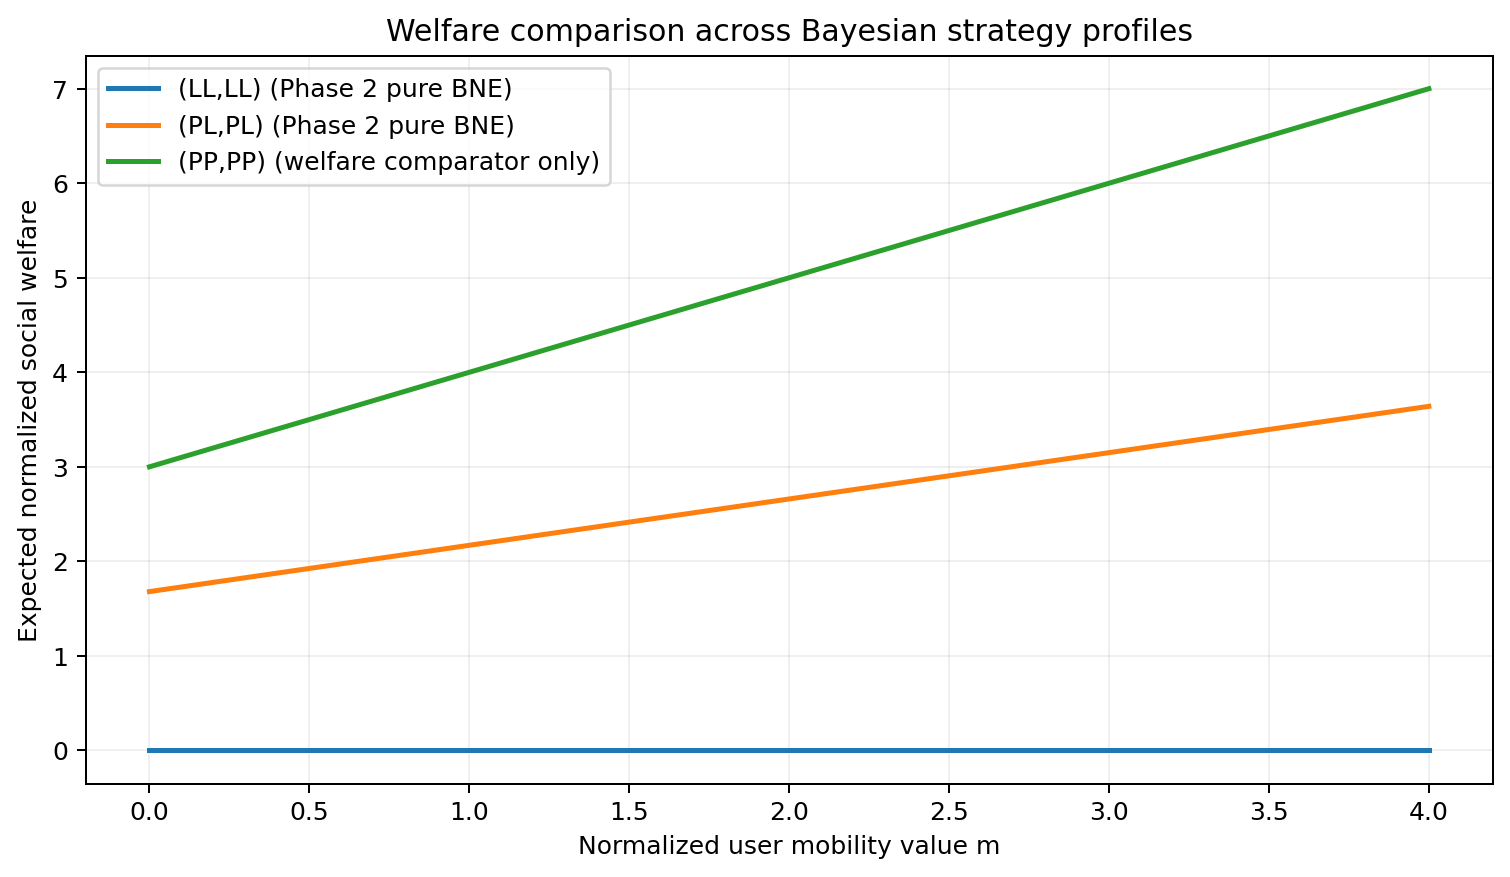

In [5]:
display(Image(filename=str(PROJECT_ROOT / "figures" / "social_welfare_by_m.png")))

### 7. Mechanism-Design Motivation

The welfare comparison exposes a gap between strategic sustainability and the
collective benchmark. The mechanism exercise asks how the equilibrium
correspondence changes when verified portability earns an additional benefit.

### 8. Portability Incentive `tau`

For a Portable action,

\[
EU_\tau(P\mid c)=3q-1-c+\tau,
\]

while `EU_tau(L|c)=q`. The neutral term *portability incentive* can represent
certification, ecosystem access, or a compliance credit; financing is not
modeled.

### 9. Analytical Threshold Shift

For `PL`, the low-type condition is
`p >= (1+c_L-tau)/2`, or `tau_min=max(0,1+c_L-2p)`. The high type must also
prefer Locked: `tau <= 1+c_H-2p`. At the benchmark, `PL` remains weakly
sustainable through `tau=0.8`, while `PP` first appears weakly at `tau=0.2`.

In [6]:
for tau in (0.39, 0.40, 0.41):
    point = ModelParameters(0.2, 1.2, 0.4)
    print(f"p=.4, tau={tau:.2f}:", enumerate_mechanism_pure_bne(point, tau))
print("Minimum tau for PL at p=.4:", minimum_incentive_for_pl(0.4, 0.2))

p=.4, tau=0.39: [('LL', 'LL'), ('PP', 'PP')]
p=.4, tau=0.40: [('LL', 'LL'), ('PL', 'PL'), ('PP', 'PP')]
p=.4, tau=0.41: [('LL', 'LL'), ('PL', 'PL'), ('PP', 'PP')]
Minimum tau for PL at p=.4: 0.3999999999999999


### 10. Full Computational Mechanism Sweep

The computation evaluates all 16 pure profiles at every combination of 99
interior prior values and 51 incentive values from 0 through 2.5. The plots
show the computed regions and analytical type boundaries.

Mechanism rows: 80784
Thresholds: {'pl_prior_threshold_at_tau_0': 0.6, 'minimum_tau_for_pl_at_p_0.4': 0.4, 'minimum_tau_for_pl_at_p_0.7': 0.0, 'll_low_type_indifference_tau': 1.2, 'll_high_type_indifference_tau': 2.2, 'pl_high_type_lock_upper_tau_at_benchmark_p': 0.8, 'pp_high_type_indifference_tau': 0.2}


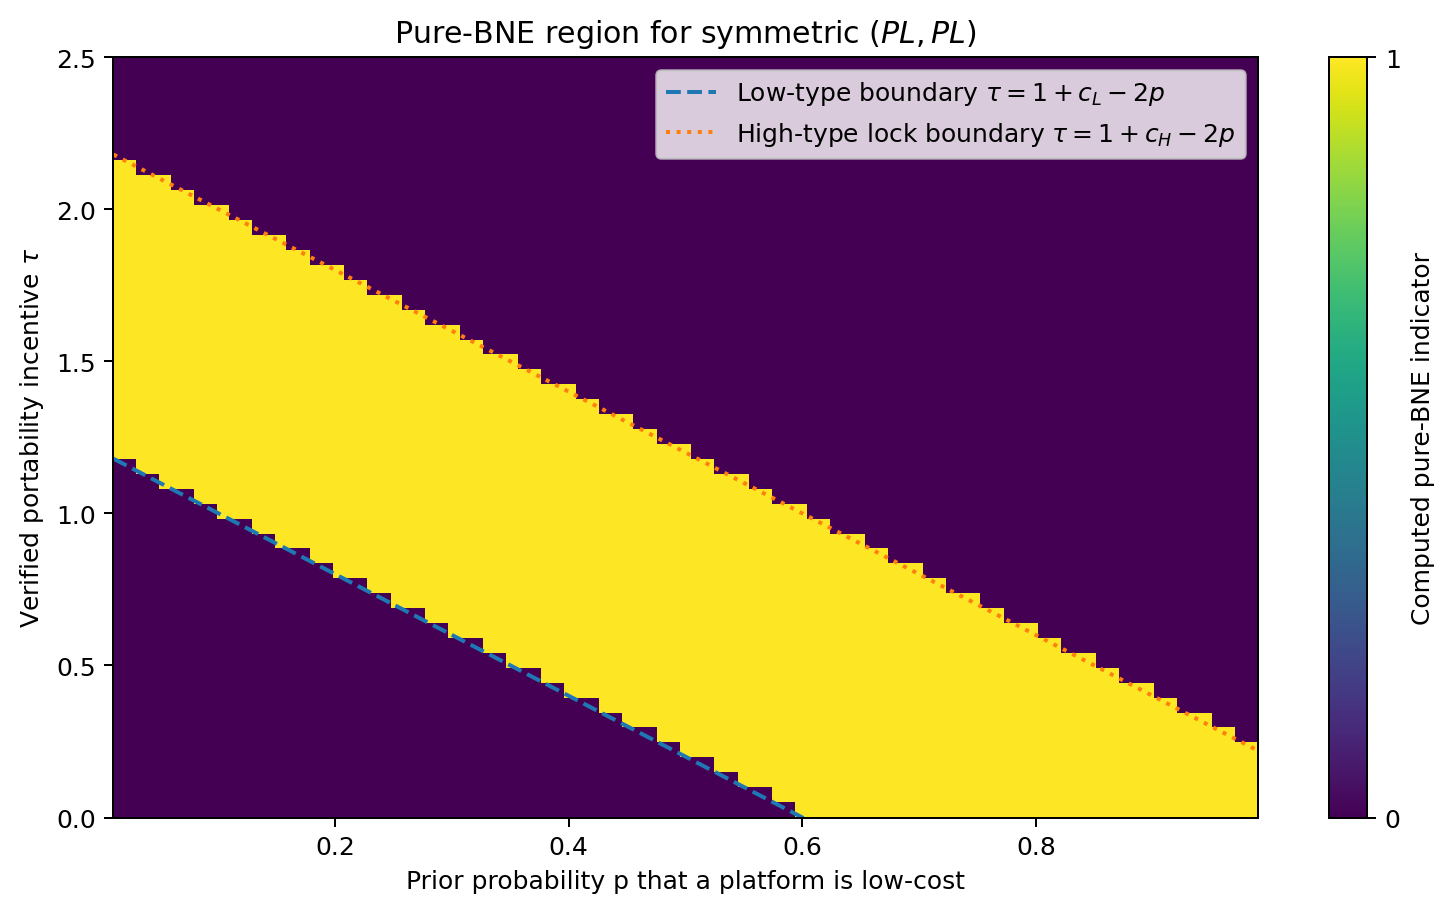

In [7]:
mechanism = pd.read_csv(PROJECT_ROOT / "outputs" / "mechanism_p_tau_sweep.csv")
thresholds = json.loads((PROJECT_ROOT / "outputs" / "mechanism_thresholds.json").read_text())
print("Mechanism rows:", len(mechanism))
print("Thresholds:", thresholds["analytical_thresholds"])
display(Image(filename=str(PROJECT_ROOT / "figures" / "pl_equilibrium_region_with_incentive.png")))

### 11. Why Equilibrium Selection Remains

`(LL,LL)` remains a weak BNE at `tau=1.2` and disappears only above that
boundary. A moderate incentive can therefore create or expand portability
equilibria while leaving lock-in available. This mechanism changes equilibrium
existence without automatically selecting the collectively preferred profile.

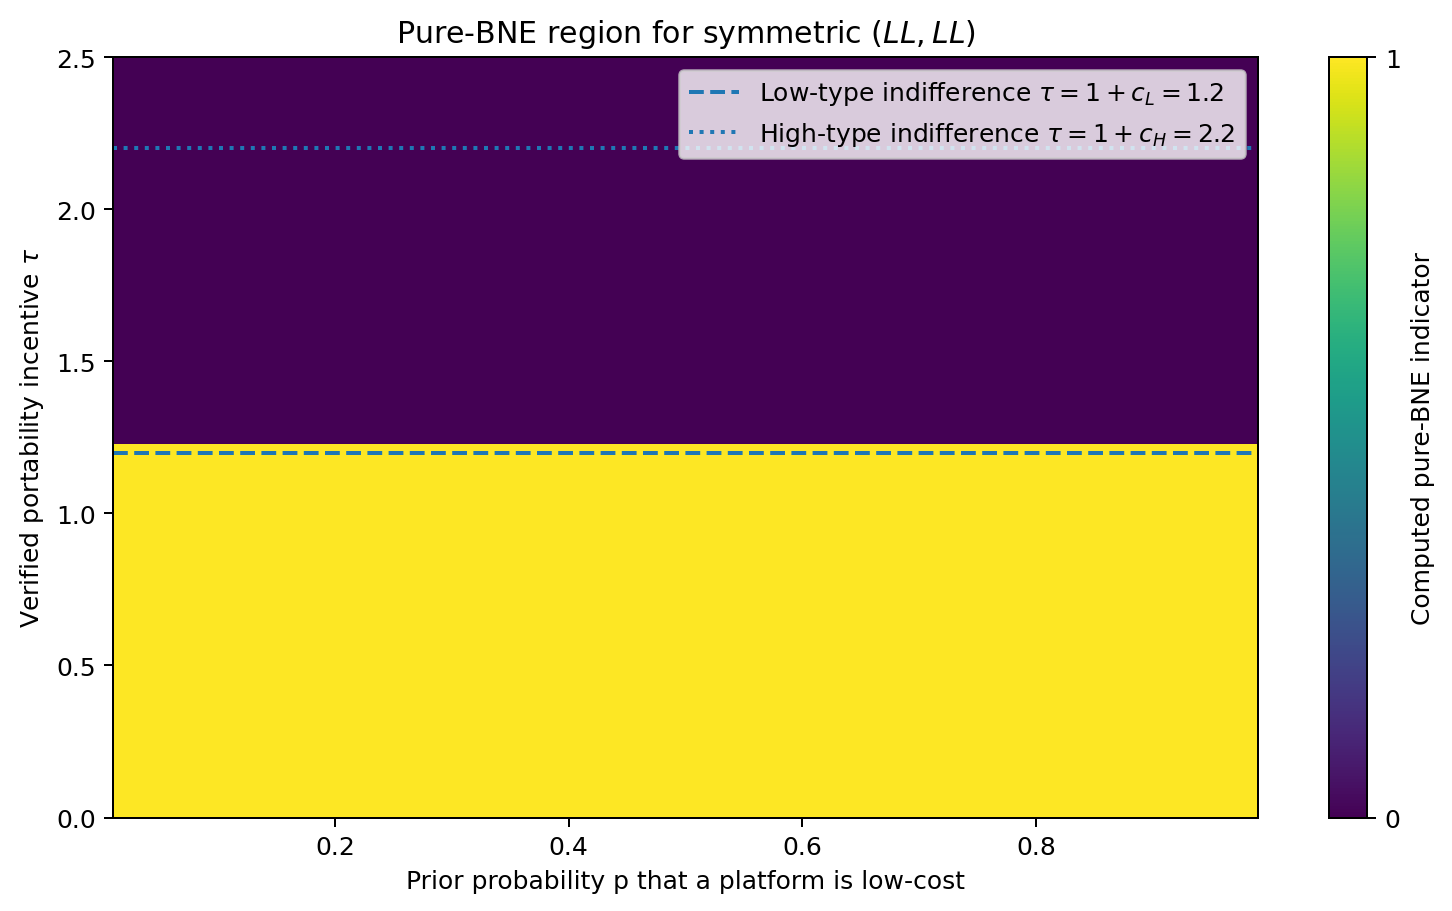

In [8]:
display(Image(filename=str(PROJECT_ROOT / "figures" / "ll_equilibrium_region_with_incentive.png")))

### 12. Auction / Allocation Application

The final lens asks how portability-induced reductions in switching friction
change competition for a mobile user. It is a stylized allocation analogy, not
a proposal to sell users.

### 13. Scarce Resource, Participants, Values, Information

- Scarce resource: one user's primary AI-assistant slot for the next service period.
- Participants: Platform A and Platform B.
- Values: iid normalized private values `Uniform(0,1)`.
- Information: each platform observes its own value; the distribution,
  mechanism, and reserve are common knowledge.
- Bids: one sealed bid per platform.
- Allocation: highest eligible bid; at most one winner.
- Tie rule: Platform A wins an exact eligible tie.
- Stopping rule: collect bids, apply the reserve, allocate, compute payment,
  and terminate.

### 14. First-Price Mechanism

The winner pays its own bid. Participating types use

\[
b_{FPA}(v;r)=\frac{v^2+r^2}{2v},\quad v\ge r,
\]

and types below `r` submit no eligible bid.

### 15. Second-Price Mechanism

Platforms bid truthfully. The highest eligible bidder wins and pays
`max(second-highest bid,r)`.

### 16. Locked vs Portable Switching Hurdle

The user's reserve is `r_locked=0.5` or `r_portable=0.2`. The reserve is placed
on the user side rather than subtracted from platform values. These are
normalized assumptions, not measured switching costs.

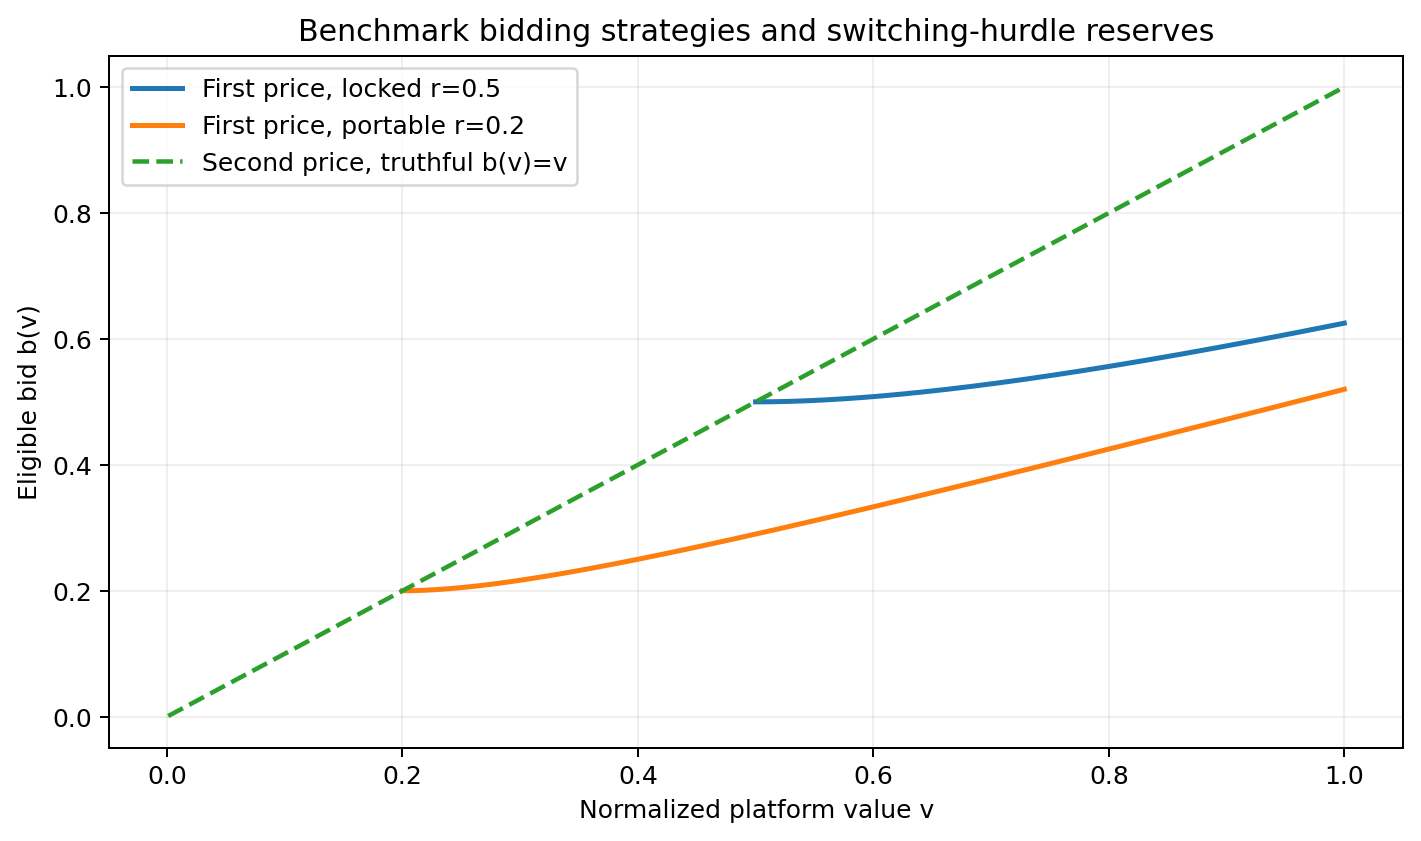

In [9]:
display(Image(filename=str(PROJECT_ROOT / "figures" / "auction_bid_functions.png")))

### 17. Simulation Results

The seeded Monte Carlo simulation uses 100,000 identical valuation profiles in
all four mechanism/reserve conditions. The analytical allocation probability
is `1-r^2`.

,mechanism,reserve_regime,reserve,n,allocation_probability,no_allocation_probability,analytical_allocation_probability,allocation_probability_absolute_error,expected_payment_unconditional,expected_payment_conditional,expected_winner_utility_unconditional,expected_winner_utility_conditional,probability_highest_value_platform_wins,efficiency_conditional_on_allocation
0,first_price,locked,0.5,100000,0.75193,0.24807,0.75,0.00193,0.417878,0.555740,0.167431,0.222669,0.75193,1.0
1,first_price,portable,0.2,100000,0.96004,0.03996,0.96,0.00004,0.363200,0.378318,0.299350,0.311809,0.96004,1.0
2,second_price,locked,0.5,100000,0.75193,0.24807,0.75,0.00193,0.418175,0.556136,0.167134,0.222273,0.75193,1.0
3,second_price,portable,0.2,100000,0.96004,0.03996,0.96,0.00004,0.364137,0.379294,0.298413,0.310834,0.96004,1.0


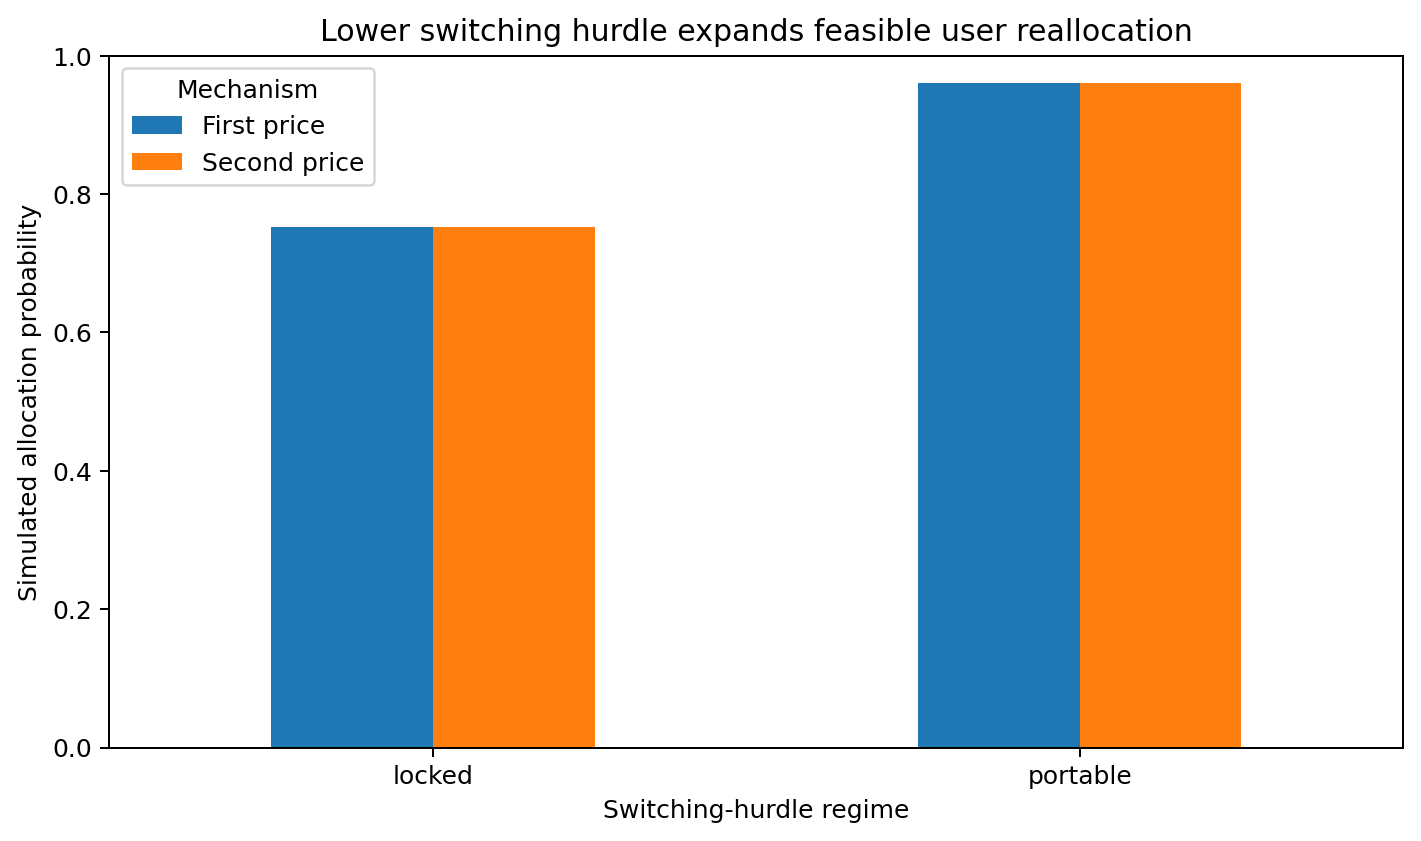

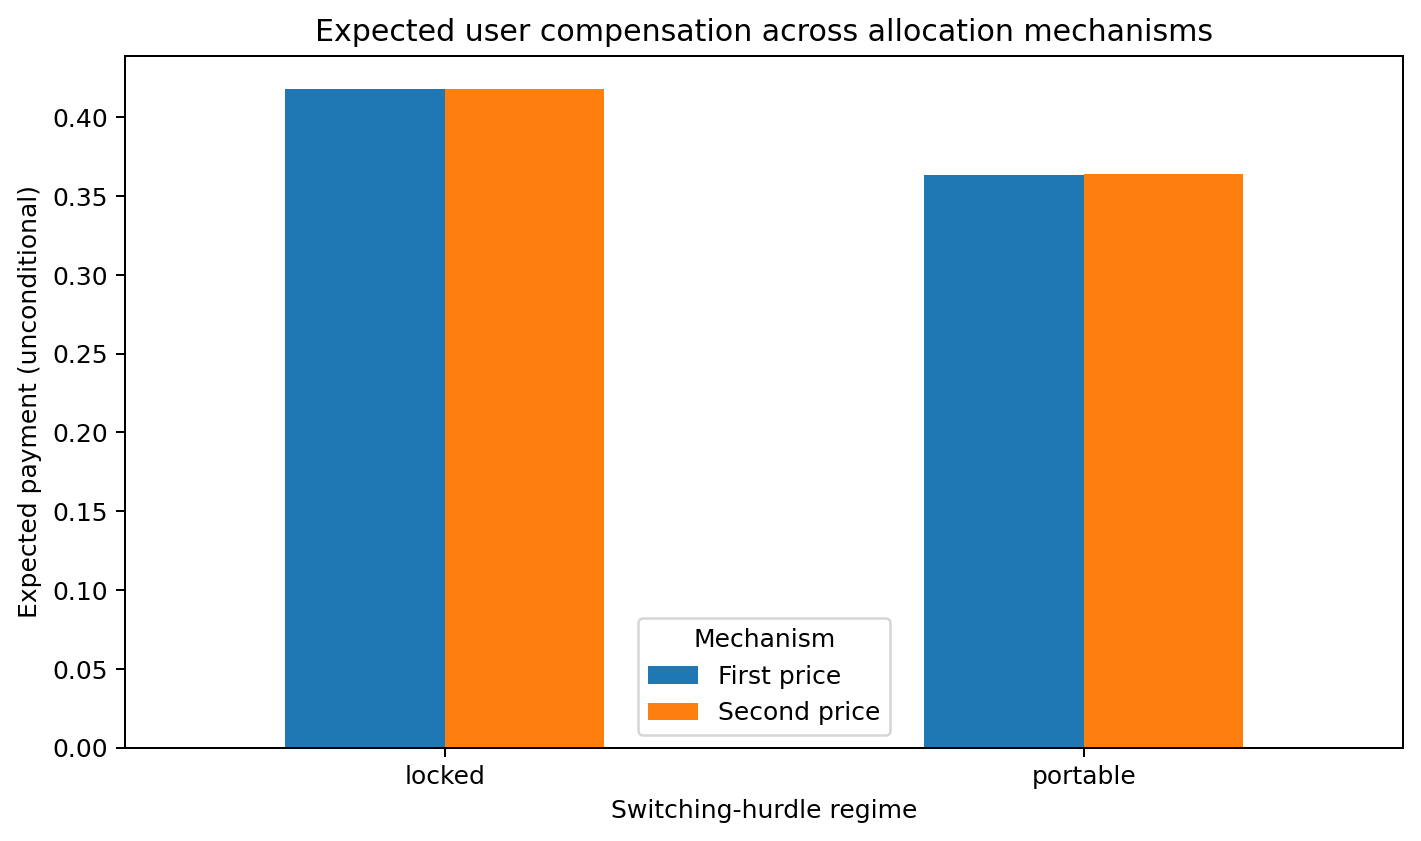

In [10]:
auction = pd.read_csv(PROJECT_ROOT / "outputs" / "auction_summary.csv")
display(auction)
display(Image(filename=str(PROJECT_ROOT / "figures" / "auction_allocation_probability.png")))
display(Image(filename=str(PROJECT_ROOT / "figures" / "auction_expected_payment.png")))

### 18. What the Auction Supports

Lowering the reserve raises feasible allocation from approximately 0.75 to
0.96 under both mechanisms. First- and second-price expected payments are close
under the symmetric risk-neutral benchmark, consistent with revenue-equivalence
logic. The portability result comes primarily through the user's lower hurdle.

### 19. Auction Boundary

The user is not literally sold. Values, reserves, and the primary-assistant
slot are normalized abstractions. The model omits multi-homing, repetition,
quality dynamics, privacy heterogeneity, network effects, entry, endogenous
user values, and multi-user markets.

### 20. Integrated Interpretation

The Bayesian game identifies decentralized equilibrium behavior and
multiplicity. Social choice compares those equilibria with a transparent user
mobility objective. Mechanism design shifts adoption incentives but reveals
that selection can remain unresolved. The auction then illustrates one channel
through which portability can matter for users: a lower switching hurdle makes
competitive reallocation feasible more often.

### 21. Limitations

- All new parameters are normalized and uncalibrated.
- Cardinal welfare comparability is assumed.
- The incentive has no financing or administrative cost.
- Equilibrium selection is not solved.
- The auction relies on symmetric, risk-neutral independent private values.
- The binary portability and one-user abstractions omit market dynamics.
- No behavioral or real-user evidence is included.

### 22. Reproducibility

From `ps2_memory_portability/`:

```bash
conda run -n cs206-ps2 python scripts/run_phase3.py
conda run -n cs206-ps2 python -m unittest discover -s tests -v
conda run -n cs206-ps2 python scripts/execute_phase3_notebook.py
```

See `docs/phase3_model_specification.md`, `docs/auction_boundary.md`, and
`docs/reproducibility.md` for formal assumptions and evidence boundaries.